# Perceptron on Diamond Carat Classification

We’ll train a Perceptron to predict whether a diamond’s carat is > 0.5, using:

- **Ordinal encoding** for `cut`, `color`, `clarity`  
- **Standard scaling + degree-2 polynomial features** on all numeric columns  
- **5-fold GridSearchCV** over the Perceptron’s hyper-parameters  

---

In [13]:
# Cell 1: Imports
import pandas as pd
import numpy as np

from sklearn.model_selection    import train_test_split, GridSearchCV
from sklearn.preprocessing     import StandardScaler, PolynomialFeatures, OrdinalEncoder
from sklearn.compose           import ColumnTransformer
from sklearn.pipeline          import Pipeline
from sklearn.linear_model      import Perceptron
from sklearn.metrics           import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix



In [3]:
# Cell 2: Load the data and create target
df = pd.read_csv("/Users/pbat/Projects/cmor438/data/diamond-prices.csv")
df['target'] = (df['carat'] > 0.5).astype(int)

# Features / target split
X = df.drop(columns=['carat','price','target'])
y = df['target']


In [4]:
# Cell 3: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [5]:
# Cell 4: Define ordinals and column lists
cut_order     = ["Fair","Good","Very Good","Premium","Ideal"]
color_order   = ["J","I","H","G","F","E","D"]
clarity_order = ["I3","I2","I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]

numeric_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols     = ["cut","color","clarity"]


In [7]:
# Cell 5: Build ColumnTransformer
numeric_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("poly",  PolynomialFeatures(degree=2, include_bias=False))
])

ordinal_enc = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order],
    dtype=float
)

preprocessor = ColumnTransformer([
    ("nums", numeric_pipe, numeric_cols),
    ("cats", ordinal_enc, cat_cols),
])


In [8]:
# Cell 6: Pipeline + parameter grid
pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", Perceptron(random_state=42))
])

param_grid = {
    "clf__penalty":   [None, "l2", "l1", "elasticnet"],
    "clf__alpha":     [1e-4, 1e-3, 1e-2],
    "clf__eta0":      [1.0, 0.1, 0.01],
    "clf__max_iter":  [500, 1000],
    "clf__tol":       [1e-3, 1e-4]
}


In [9]:
# Cell 7: Run grid search
gs = GridSearchCV(
    pipe,
    param_grid = param_grid,
    cv         = 5,
    scoring    = "accuracy",
    n_jobs     = -1,
    verbose    = 1
)

gs.fit(X_train, y_train)
print(f"\n→ Best CV accuracy: {gs.best_score_:.4f}")
print("→ Best hyper‐parameters:", gs.best_params_)


Fitting 5 folds for each of 144 candidates, totalling 720 fits

→ Best CV accuracy: 0.9891
→ Best hyper‐parameters: {'clf__alpha': 0.0001, 'clf__eta0': 1.0, 'clf__max_iter': 500, 'clf__penalty': 'l1', 'clf__tol': 0.001}


In [10]:
# Cell 8: Test‐set performance
y_pred = gs.predict(X_test)

print("\nTest‐set classification report:")
print(classification_report(y_test, y_pred, target_names=["≤0.5 carat",">0.5 carat"]))

print("Test‐set confusion matrix:")
print(confusion_matrix(y_test, y_pred))



Test‐set classification report:
              precision    recall  f1-score   support

  ≤0.5 carat       0.99      0.97      0.98      3502
  >0.5 carat       0.98      1.00      0.99      6498

    accuracy                           0.99     10000
   macro avg       0.99      0.98      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Test‐set confusion matrix:
[[3403   99]
 [  32 6466]]


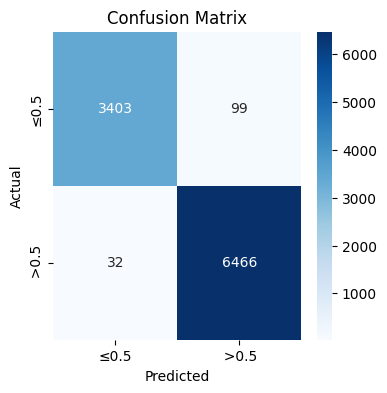

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["≤0.5"," >0.5"], yticklabels=["≤0.5"," >0.5"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Number of features after preprocessing: 23
Number of weights: 23


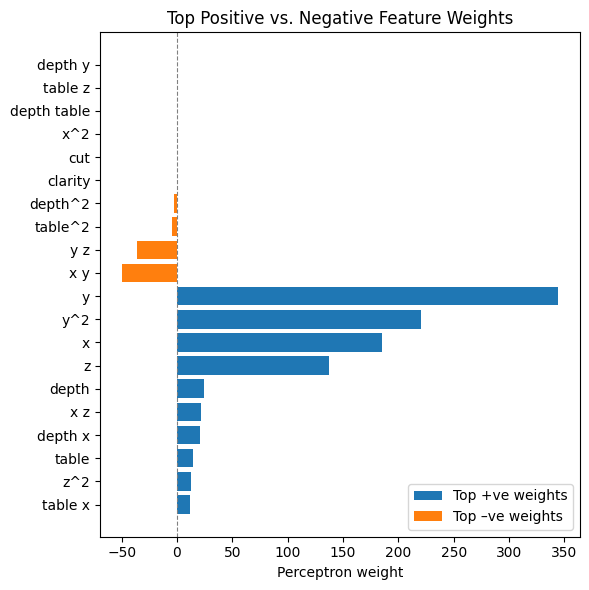

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Pull out the fitted ColumnTransformer
pre = gs.best_estimator_.named_steps["pre"]

# 2) Get numeric feature names AFTER the poly‐expansion
num_in = numeric_cols
poly = pre.named_transformers_["nums"].named_steps["poly"]
poly_feature_names = poly.get_feature_names_out(input_features=num_in)

# 3) Get encoded names
cat_enc = pre.named_transformers_["cats"]
cat_feature_names = cat_enc.get_feature_names_out(cat_cols)

# 4) Combine
all_feats = np.concatenate([poly_feature_names, cat_feature_names])
n_feats = len(all_feats)
print(f"Number of features after preprocessing: {n_feats}")

# 5) Grab the learned weights
w = gs.best_estimator_.named_steps["clf"].coef_.ravel()
print(f"Number of weights: {len(w)}")

# 6) Choose top_k
top_k = min(10, n_feats//2)

# 7) Sort and pick
sorted_idx = np.argsort(w)
idx_pos = sorted_idx[-top_k:]    # top_k largest
idx_neg = sorted_idx[:top_k]     # top_k smallest

# 8) Plot
plt.figure(figsize=(6,6))
plt.barh(all_feats[idx_pos], w[idx_pos], color="C0", label="Top +ve weights")
plt.barh(all_feats[idx_neg], w[idx_neg], color="C1", label="Top –ve weights")
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Perceptron weight")
plt.title("Top Positive vs. Negative Feature Weights")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Discussion of Results

- **Overall performance**  
  - **Accuracy**: 0.99  
  - **Macro-average F₁-score**: 0.99  

- **Class “≤ 0.5 carat”**  
  - Precision 0.99 → almost no small diamonds predicted as large  
  - Recall 0.97 → 3 % of true small diamonds are misclassified  

- **Class “> 0.5 carat”**  
  - Precision 0.98 → very few false alarms on large diamonds  
  - Recall 1.00 → all true large diamonds are correctly identified  

- **Confusion matrix**  
  - True “≤ 0.5”: 3 403, False “> 0.5”: 99  
  - False “≤ 0.5”: 32, True “> 0.5”: 6 466  

- **Key features**  
  - **Top positive weights**:  
    - `y` (length) and `y²` – larger y strongly signals > 0.5 carat  
    - `x` (width) and `z` (depth) – also boost probability of “large”  
  - **Top negative weights**:  
    - Interaction terms like `x*y` and `y*z` – when those combinations are small, they push toward “small”  
    - `table` and `table²`  

### Takeaways

1. The Perceptron separates the two carat classes nearly perfectly, with only 1 % total misclassifications.  
2. Most errors occur right at the 0.5 carat boundary—consider adding a small “margin” feature or a probabilistic threshold to handle borderline cases.  

